## Hyperliquid vs Market Sentiment Analysis  

To analyze the relationship between Bitcoin market sentiment (Fear/Greed) and trader behavior on Hyperliquid.

The goal is to identify whether market sentiment influences:

- Trader profitability (PnL)
- Win rates
- Trading frequency
- Position sizes
- Long/Short trading bias




## Datasets

### 1. Bitcoin Market Sentiment Dataset

Contains daily market sentiment classifications:

- Fear
- Greed

Columns:

- Date
- Classification

### 2. Hyperliquid Historical Trader Dataset

Contains historical trading activity including:

- Account information
- Trading symbols
- Position size
- Trade direction
- Profit/Loss

In [53]:
#Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [54]:
#Load Fear/Greed dataset
fg=pd.read_csv('fear_greed_index.csv')

#Load Hyperliquid historical dataset
trades=pd.read_csv('historical_data.csv')

In [55]:
#Check no. of rows and column of each dataset
fg.shape

(2644, 4)

In [56]:
trades.shape

(211224, 16)

In [57]:
fg.head()       #Display first 5 rows for overview

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [58]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.8700,7872.1600,BUY,02-12-2024 22:50,0.0000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.3454,895000000000000.0000,1730000000000.0000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.0000,127.6800,BUY,02-12-2024 22:50,986.5246,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0056,443000000000000.0000,1730000000000.0000
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.0900,1150.6300,BUY,02-12-2024 22:50,1002.5190,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0504,660000000000000.0000,1730000000000.0000
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.9800,1142.0400,BUY,02-12-2024 22:50,1146.5586,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0500,1080000000000000.0000,1730000000000.0000
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.7300,69.7500,BUY,02-12-2024 22:50,1289.4885,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0031,1050000000000000.0000,1730000000000.0000


In [59]:
# Fear/Greed overview
print("FEAR/GREED")
print("Rows:", fg.shape[0], " Cols:", fg.shape[1])
print("\nColumn names:", fg.columns.tolist())
print("\nMissing values:\n", fg.isnull().sum())
print("\nDuplicates:", fg.duplicated().sum())

# Trades overview
print("\nTRADES")
print("Rows:", trades.shape[0], " Cols:", trades.shape[1])
print("\nColumn names:", trades.columns.tolist())
print("\nMissing values:\n", trades.isnull().sum())
print("\nDuplicates:", trades.duplicated().sum())
print("\nData types:\n", trades.dtypes)

FEAR/GREED
Rows: 2644  Cols: 4

Column names: ['timestamp', 'value', 'classification', 'date']

Missing values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates: 0

TRADES
Rows: 211224  Cols: 16

Column names: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates: 0

Data types:
 Account              object
Coin                 object
Execution Price     float64
Size Tokens         float6

**Fear/Greed:** 2644 rows, columns are timestamp, value, classification, date ,no missing, no duplicates. Clean.  
  
**Trades:** 211,224 rows, 16 columns. Two timestamp columns — Timestamp IST (string-looking) and Timestamp (float64).   
No missing values on the core columns.
  
    
      

In [60]:
# Check what date column looks like in Fear/Greed

print("FG date sample:")
print(fg['date'].head(5))

# Check both timestamp columns in trades

print("\nTrades 'Timestamp IST' sample:")
print(trades['Timestamp IST'].head(5))

print("\nTrades 'Timestamp' (float) sample:")
print(trades['Timestamp'].head(5))

FG date sample:
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object

Trades 'Timestamp IST' sample:
0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: object

Trades 'Timestamp' (float) sample:
0   1730000000000.0000
1   1730000000000.0000
2   1730000000000.0000
3   1730000000000.0000
4   1730000000000.0000
Name: Timestamp, dtype: float64


### **Convert Timestamps & Align by date**
As the date in fear/greed is in string and for trades , timestamp col1 has string IST format and timestamp col2 has float value thats milliseconds.  

we will convert and align them by date.

In [61]:
# FG date string to datetime
fg['date'] = pd.to_datetime(fg['date'])
print(fg['date'].head(3))

0   2018-02-01
1   2018-02-02
2   2018-02-03
Name: date, dtype: datetime64[ns]


In [62]:
#Trades Timestamp 

trades['datetime_ist'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
#(format is DD-MM-YYYY HH:MM)

# Extract date only (we align at daily level)
trades['date'] = trades['datetime_ist'].dt.normalize()
print(trades['date'].head(3))


0   2024-12-02
1   2024-12-02
2   2024-12-02
Name: date, dtype: datetime64[ns]


 ###  **Does market sentiment (Fear/Greed) affect trader behavior and performance?**  
  To answer this, we need to merge and analyze.


**If date ranges actually overlap** Fear/Greed starts 2018, trades start around Nov 2024 based on the timestamp.  

if there's no overlap the merge will produce nothing useful.

In [63]:
print("FG date range   :", fg['date'].min(), "→", fg['date'].max())
print("Trades date range:", trades['date'].min(), "→", trades['date'].max())

FG date range   : 2018-02-01 00:00:00 → 2025-05-02 00:00:00
Trades date range: 2023-05-01 00:00:00 → 2025-05-01 00:00:00


  
The Fear/Greed dataset spans a broader period than the trading dataset.   
Since all trade dates fall within sentiment date range, date-based merge can be performed successfully.
  
**Left join** can be done , pandas looks up each trade's date in the FG table and stamps that day's sentiment onto the trade

In [64]:
# Keep only the FG columns we need
fg_slim = fg[['date', 'value', 'classification']].copy()

# Merge trades with FG on date (left join — keep all trades, attach sentiment)
merged = trades.merge(fg_slim, on='date', how='left')

print("Trades before merge :", len(trades))
print("Trades after merge  :", len(merged))
print("Rows with no FG match:", merged['value'].isnull().sum())

Trades before merge : 211224
Trades after merge  : 211224
Rows with no FG match: 6


In [65]:
# Drop the 6 rows with no FG match
merged = merged.dropna(subset=['value'])
print("Rows after dropping nulls:", len(merged))

Rows after dropping nulls: 211218


In [66]:
# merged result
merged[['Account', 'Coin', 'date', 'value', 'classification']].head(5)

,Account,Coin,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,80.0000,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,80.0000,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,80.0000,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,80.0000,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,80.0000,Extreme Greed


In [97]:
print("Match Rate:",
      round(
          (merged['classification'].notna().mean())*100,2),"%")

Match Rate: 100.0 %


**100% of trades were successfully matched to a sentiment label.**

In [67]:
# How many trades exist per year?
print(trades['date'].dt.year.value_counts().sort_index())

date
2023       344
2024     52497
2025    158383
Name: count, dtype: int64


In [68]:
# What does the actual earliest trade look like?
print(trades.sort_values('date').head(3)[['Account', 'Coin', 'date', 'Timestamp IST']])

                                          Account Coin       date  \
83771  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  ETH 2023-05-01   
83769  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  ETH 2023-05-01   
83770  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  ETH 2023-05-01   

          Timestamp IST  
83771  01-05-2023 01:06  
83769  01-05-2023 01:06  
83770  01-05-2023 01:06  


### **NOTE: Data distribution by year**  
  
 2023 -    344 trades (0.16%) - platform early stage, ignore or treat separately  
 2024 -  52,497 trades (24.8%)  
 2025 - 158,383 trades (75.0%)  
   
 Analysis will focus on 2024–2025 where data is meaningful.  

In [69]:
# Clean column names — lowercase, replace spaces with underscores
merged.columns = merged.columns.str.strip().str.lower().str.replace(' ', '_')

# Check the result
for col in merged.columns:
    print(col)

account
coin
execution_price
size_tokens
size_usd
side
timestamp_ist
start_position
direction
closed_pnl
transaction_hash
order_id
crossed
fee
trade_id
timestamp
datetime_ist
date
value
classification


there's no leverage column, that's important. We have side and direction which may both carry long/short info.

### **Exploring key columns for metrics**

Q1 Are side and direction the same thing or different? (one might be Buy/Sell, other Long/Short)

In [70]:
print("side values:\n", merged['side'].value_counts())
print("\ndirection values:\n", merged['direction'].value_counts())

side values:
 side
SELL    108528
BUY     102690
Name: count, dtype: int64

direction values:
 direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36007
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64


Q2 Does closed_pnl have zeros? (those are likely open trades or funding events, not closed trades)

In [71]:
# Check closed_pnl — are there zeros? negatives?
print("closed_pnl stats:\n", merged['closed_pnl'].describe())
print("\nZero PnL rows:", (merged['closed_pnl'] == 0).sum())

closed_pnl stats:
 count    211218.0000
mean         48.5493
std         917.9898
min     -117990.1041
25%           0.0000
50%           0.0000
75%           5.7901
max      135329.0901
Name: closed_pnl, dtype: float64

Zero PnL rows: 106816


**106,816 rows have zero PnL — 50% of the data.** These are Open Long / Open Short rows — trades that were opened but not yet closed, so no PnL realized yet

Q3 Are there any negative size_usd values?

In [72]:
# Check size_usd
print("size_usd stats:\n", merged['size_usd'].describe())

size_usd stats:
 count    211218.0000
mean       5639.1916
std       36575.5733
min           0.0000
25%         193.7900
50%         597.0200
75%        2058.8775
max     3921430.7200
Name: size_usd, dtype: float64


In [73]:
# Keep only rows where a position was actually closed (PnL was realized)
closed_trades = merged[merged['direction'].isin(['Close Long', 'Close Short'])].copy()

print("All trades      :", len(merged))
print("Closed trades   :", len(closed_trades))
print("\ndirection check:\n", closed_trades['direction'].value_counts())

All trades      : 211218
Closed trades   : 84685

direction check:
 direction
Close Long     48678
Close Short    36007
Name: count, dtype: int64


In [74]:
# win flag — did this trade make money?
closed_trades['is_win'] = closed_trades['closed_pnl'] > 0

print("\nWin/Loss split:")
print(closed_trades['is_win'].value_counts())


Win/Loss split:
is_win
True     70748
False    13937
Name: count, dtype: int64


84,685 closed trades (down from 211,218 — the rest were opens/funding/dust)  
Close Long: 48,678 | Close Short: 36,007 — good balance  
Win/Loss: 70,748 wins vs 13,937 losses — overall win rate of ~83.5% which seems high, we'll dig into this per trader later  

In [75]:
# Check what classifications exist
print(closed_trades['classification'].value_counts())

classification
Fear             26481
Greed            19320
Neutral          15843
Extreme Greed    13683
Extreme Fear      9358
Name: count, dtype: int64


### **Sentiment binary column**  
  
Before building metrics, simplifying classification into just Fear/Greed.

In [76]:
# Create simplified sentiment column
def simplify_sentiment(c):
    if 'Fear' in str(c):
        return 'Fear'
    elif 'Greed' in str(c):
        return 'Greed'
    else:
        return 'Neutral'

closed_trades['sentiment'] = closed_trades['classification'].apply(simplify_sentiment)
print(closed_trades['sentiment'].value_counts())

sentiment
Fear       35839
Greed      33003
Neutral    15843
Name: count, dtype: int64


### **Daily performance metrics**  -
  
  Q. Does performance differ between Fear and Greed days?

In [77]:
daily = closed_trades.groupby('date').agg(
    total_pnl      = ('closed_pnl', 'sum'),
    avg_pnl        = ('closed_pnl', 'mean'),
    n_trades       = ('closed_pnl', 'count'),
    win_rate       = ('is_win', 'mean'),
    avg_size_usd   = ('size_usd', 'mean'),
    long_count     = ('direction', lambda x: (x == 'Close Long').sum()),
    short_count    = ('direction', lambda x: (x == 'Close Short').sum()),
    sentiment      = ('sentiment', 'first'),
    fgi_value      = ('value', 'first')
).reset_index()

# Long/short ratio
daily['long_ratio'] = daily['long_count'] / (daily['long_count'] + daily['short_count'])

print("Daily metrics shape:", daily.shape)
print(daily.head())

Daily metrics shape: (409, 11)
        date  total_pnl  avg_pnl  n_trades  win_rate  avg_size_usd  \
0 2023-12-14  -205.4347 -34.2391         6    0.6667    12789.3983   
1 2023-12-15   -24.6320 -12.3160         2    0.0000     5304.9750   
2 2023-12-17   304.9828  27.7257        11    0.6364     5996.8918   
3 2023-12-19  1000.5386 100.0539        10    1.0000     6188.3490   
4 2023-12-20   162.7323  20.3415         8    1.0000     8862.4688   

   long_count  short_count sentiment  fgi_value  long_ratio  
0           4            2     Greed    72.0000      0.6667  
1           0            2     Greed    70.0000      0.0000  
2          11            0     Greed    73.0000      1.0000  
3          10            0     Greed    73.0000      1.0000  
4           8            0     Greed    74.0000      1.0000  




These daily metrics were used to compare trader performance and behavior across Fear and Greed market conditions.

### **Per-trade metrics** -

In [78]:
trader = closed_trades.groupby('account').agg(
    total_pnl    = ('closed_pnl', 'sum'),
    avg_pnl      = ('closed_pnl', 'mean'),
    n_trades     = ('closed_pnl', 'count'),
    win_rate     = ('is_win', 'mean'),
    avg_size_usd = ('size_usd', 'mean'),
    total_volume = ('size_usd', 'sum'),
    long_count   = ('direction', lambda x: (x == 'Close Long').sum()),
    short_count  = ('direction', lambda x: (x == 'Close Short').sum()),
).reset_index()

# Long ratio per trader
trader['long_ratio'] = trader['long_count'] / (trader['long_count'] + trader['short_count'])

# Max drawdown proxy — minimum cumulative PnL drop
def max_drawdown(pnl_series):
    cum = pnl_series.cumsum()
    return (cum - cum.cummax()).min()

drawdowns = (closed_trades.sort_values('date')
             .groupby('account')['closed_pnl']
             .apply(max_drawdown)
             .reset_index(name='max_drawdown'))

trader = trader.merge(drawdowns, on='account')

print("Trader metrics shape:", trader.shape)
print(trader.sort_values('total_pnl', ascending=False).head())

Trader metrics shape: (32, 11)
                                       account    total_pnl  avg_pnl  \
0   0x083384f897ee0f19899168e3b1bec365f52a9012 1599059.9606 923.7781   
29  0xbaaaf6571ab7d571043ff1e313a9609a10637864  940132.3858  94.0603   
27  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  725029.6449 138.7086   
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  685324.3206 308.1494   
13  0x513b8629fe877bb581bf244e326a047b249c4ff1  664245.3895 131.6119   

    n_trades  win_rate  avg_size_usd   total_volume  long_count  short_count  \
0       1731    0.7926    17310.4576  29964402.1900         295         1436   
29      9995    0.9912     3481.3289  34795882.0800        9995            0   
27      5227    0.7821     5019.4991  26236921.9200        2306         2921   
11      2224    0.9523     9040.3358  20105706.7800        2017          207   
13      5047    0.8805    41459.6565 209246886.3700        3988         1059   

    long_ratio  max_drawdown  
0       0.1704  -325060.

These metrics were later used for trader segmentation and performance comparison.

**Limitation** -Since leverage information was not available in the dataset, Therefore, trade size was analyzed to understand trader exposure and behavior.  
Results related to risk-taking behavior should therefore be interpreted cautiously.



### **Q1 Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?**
  
  To check whether market sentiments have an impact on traders outcome.

In [79]:
# Group daily metrics by sentiment
sentiment_perf = daily.groupby('sentiment').agg(
    avg_daily_pnl  = ('total_pnl', 'mean'),
    median_pnl     = ('total_pnl', 'median'),
    avg_win_rate   = ('win_rate', 'mean'),
    avg_trade_cnt  = ('n_trades', 'mean'),
    avg_size_usd   = ('avg_size_usd', 'mean'),
    avg_long_ratio = ('long_ratio', 'mean'),
    days_count     = ('date', 'count')
).reset_index()

print(sentiment_perf)

  sentiment  avg_daily_pnl  median_pnl  avg_win_rate  avg_trade_cnt  \
0      Fear     52332.8360  13526.9756        0.8746       442.4568   
1     Greed      7185.9533   1151.4370        0.8392       120.4489   
2   Neutral     20043.4554   5351.2818        0.8114       293.3889   

   avg_size_usd  avg_long_ratio  days_count  
0     8171.2180          0.5975          81  
1     6628.6251          0.5184         274  
2     9284.7911          0.6681          54  


Shows that **Fear days** = 81 days, **Greed days** = 274 days, **Neutral days** = 54 days.
  
  So **Fear days outperform Greed days in PnL.** Also traders are far more active on Fear days.
               

In [80]:
from scipy import stats

# Get daily PnL for each sentiment group
fear_pnl   = daily[daily['sentiment'] == 'Fear']['total_pnl']
greed_pnl  = daily[daily['sentiment'] == 'Greed']['total_pnl']
neutral_pnl= daily[daily['sentiment'] == 'Neutral']['total_pnl']

# T-test: Fear vs Greed
t, p = stats.ttest_ind(fear_pnl, greed_pnl)
print(f"Fear vs Greed PnL — t={t:.3f}, p={p:.4f}")

# Win rate
fear_wr  = daily[daily['sentiment'] == 'Fear']['win_rate']
greed_wr = daily[daily['sentiment'] == 'Greed']['win_rate']
t2, p2 = stats.ttest_ind(fear_wr, greed_wr)
print(f"Fear vs Greed Win Rate — t={t2:.3f}, p={p2:.4f}")

Fear vs Greed PnL — t=5.471, p=0.0000
Fear vs Greed Win Rate — t=1.213, p=0.2261


**Pnl difference: p=0.0000**  
**Win rate: p=0.2261**   
Fear days were associated with significantly higher average daily PnL.

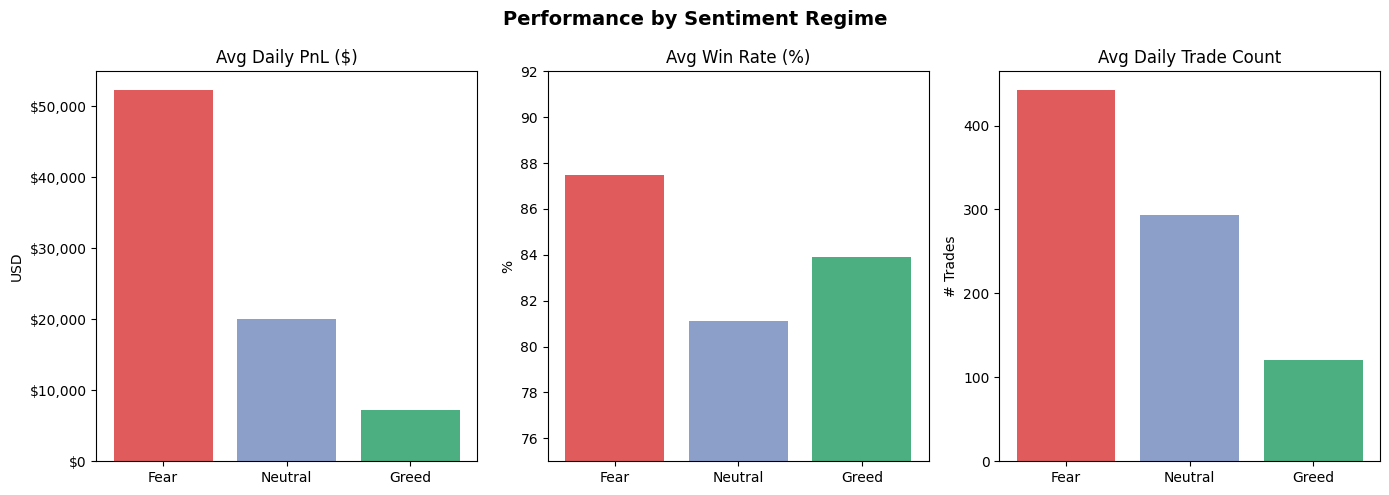

In [81]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Performance by Sentiment Regime', fontsize=14, fontweight='bold')

colors = {'Fear': '#e05c5c', 'Greed': '#4caf82', 'Neutral': '#8b9fc8'}
order  = ['Fear', 'Neutral', 'Greed']
perf   = sentiment_perf.set_index('sentiment').loc[order]

# Chart 1 — Avg Daily PnL
axes[0].bar(order, perf['avg_daily_pnl'],
            color=[colors[s] for s in order])
axes[0].set_title('Avg Daily PnL ($)')
axes[0].set_ylabel('USD')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Chart 2 — Avg Win Rate
axes[1].bar(order, perf['avg_win_rate'] * 100,
            color=[colors[s] for s in order])
axes[1].set_title('Avg Win Rate (%)')
axes[1].set_ylabel('%')
axes[1].set_ylim(75, 92)

# Chart 3 — Avg Trade Count
axes[2].bar(order, perf['avg_trade_cnt'],
            color=[colors[s] for s in order])
axes[2].set_title('Avg Daily Trade Count')
axes[2].set_ylabel('# Trades')

plt.tight_layout()
plt.savefig('Performance_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

- Fear days are surprisingly the most profitable - traders made **7× more
  money on Fear days** ($52,332) than on Greed days ($7,185)

- Win rates barely changed across sentiments ,meaning traders weren't
  making **better decisions**, they were just **trading more and bigger**

- Higher profitability during Fear periods appears to be driven largely by increased trading activity and larger position sizes rather than improved win rates.

### **Q2 Do traders change behavior based on sentiment?**


In [82]:
# Behavioral metrics by sentiment
behavior = closed_trades.groupby('sentiment').agg(
    avg_size_usd   = ('size_usd', 'mean'),
    median_size_usd= ('size_usd', 'median'),
    long_ratio     = ('direction', lambda x: (x == 'Close Long').mean()),
    trade_count    = ('closed_pnl', 'count')
).reset_index()

print(behavior)

  sentiment  avg_size_usd  median_size_usd  long_ratio  trade_count
0      Fear     8080.2831         814.1400      0.6557        35839
1     Greed     5318.3403         554.9900      0.4601        33003
2   Neutral     6110.9021         573.7300      0.6308        15843


Median-based splits were used because trade counts and position sizes were highly skewed, making mean-based thresholds less representative.

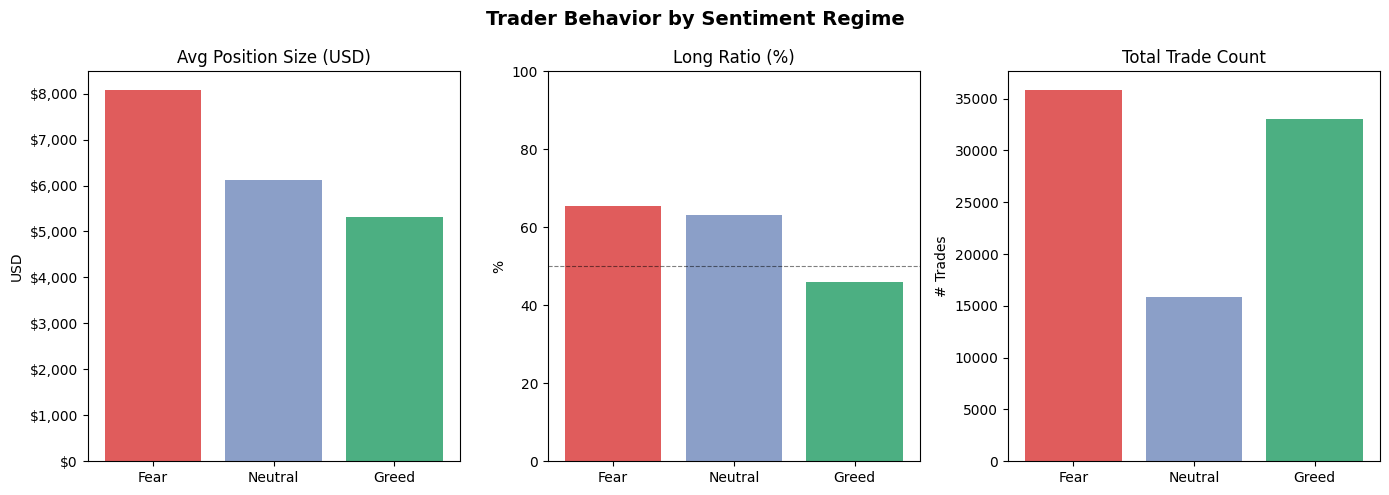

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Trader Behavior by Sentiment Regime', 
             fontsize=14, fontweight='bold')

order  = ['Fear', 'Neutral', 'Greed']
colors = {'Fear': '#e05c5c', 'Greed': '#4caf82', 'Neutral': '#8b9fc8'}
beh    = behavior.set_index('sentiment').loc[order]

# Chart 1 — Avg Position Size
axes[0].bar(order, beh['avg_size_usd'],
            color=[colors[s] for s in order])
axes[0].set_title('Avg Position Size (USD)')
axes[0].set_ylabel('USD')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Chart 2 — Long Ratio
axes[1].bar(order, beh['long_ratio'] * 100,
            color=[colors[s] for s in order])
axes[1].set_title('Long Ratio (%)')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
axes[1].axhline(50, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# Chart 3 — Trade Count
axes[2].bar(order, beh['trade_count'],
            color=[colors[s] for s in order])
axes[2].set_title('Total Trade Count')
axes[2].set_ylabel('# Trades')

plt.tight_layout()
plt.savefig('Behavior_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

- During Fear, traders **bet bigger** — position sizes were 52% larger
  than on Greed days. 

- **Surprising:** traders went mostly long during Fear (65%) but
  switched to shorting during Greed (54% short). 

### **Trader Segmentation**  
  
  Three segments:
1. Frequent vs Infrequent traders (by trade count)
2. Consistent Winners vs Losers (by total PnL)
3. High vs Low position size (by avg size_usd)

In [84]:
# Check trader dataframe
print("Total unique traders:", len(trader))
print(trader[['total_pnl', 'n_trades', 'avg_size_usd', 'win_rate']].describe())

Total unique traders: 32
         total_pnl   n_trades  avg_size_usd  win_rate
count      32.0000    32.0000       32.0000   32.0000
mean   227820.5468  2646.4062     7598.6856    0.8426
std    359999.2078  3092.3353     9126.9715    0.1467
min   -155996.6081     6.0000      572.0383    0.3333
25%     12194.9870   479.0000     1987.7042    0.7672
50%     73910.2868  1649.5000     3551.5860    0.8561
75%    321428.0528  3434.0000     9435.6209    0.9558
max   1599059.9606 12100.0000    41459.6565    1.0000


In [85]:
# Segment 1 — Frequent vs Infrequent (split at median trade count)
median_trades = trader['n_trades'].median()
trader['freq_segment'] = trader['n_trades'].apply(
    lambda x: 'Frequent' if x >= median_trades else 'Infrequent')

# Segment 2 — Winners vs Losers (split at 0)
trader['pnl_segment'] = trader['total_pnl'].apply(
    lambda x: 'Winner' if x > 0 else 'Loser')

# Segment 3 — High vs Low position size (split at median)
median_size = trader['avg_size_usd'].median()
trader['size_segment'] = trader['avg_size_usd'].apply(
    lambda x: 'High Size' if x >= median_size else 'Low Size')

# Quick check
print("Median trade count:", median_trades)
print("Median size_usd:", median_size)
print("\nFrequent vs Infrequent:\n", trader['freq_segment'].value_counts())
print("\nWinners vs Losers:\n", trader['pnl_segment'].value_counts())
print("\nHigh vs Low Size:\n", trader['size_segment'].value_counts())

Median trade count: 1649.5
Median size_usd: 3551.5859962630025

Frequent vs Infrequent:
 freq_segment
Frequent      16
Infrequent    16
Name: count, dtype: int64

Winners vs Losers:
 pnl_segment
Winner    29
Loser      3
Name: count, dtype: int64

High vs Low Size:
 size_segment
High Size    16
Low Size     16
Name: count, dtype: int64


In [86]:
# Segment comparison table
seg_summary = trader.groupby('freq_segment').agg(
    avg_pnl    = ('total_pnl', 'mean'),
    avg_winrate= ('win_rate', 'mean'),
    avg_trades = ('n_trades', 'mean'),
    avg_size   = ('avg_size_usd', 'mean')
).reset_index().rename(columns={'freq_segment': 'segment'})

seg_summary2 = trader.groupby('size_segment').agg(
    avg_pnl    = ('total_pnl', 'mean'),
    avg_winrate= ('win_rate', 'mean'),
    avg_trades = ('n_trades', 'mean'),
    avg_size   = ('avg_size_usd', 'mean')
).reset_index().rename(columns={'size_segment': 'segment'})

seg_summary3 = trader.groupby('pnl_segment').agg(
    avg_pnl    = ('total_pnl', 'mean'),
    avg_winrate= ('win_rate', 'mean'),
    avg_trades = ('n_trades', 'mean'),
    avg_size   = ('avg_size_usd', 'mean')
).reset_index().rename(columns={'pnl_segment': 'segment'})

print("Frequent vs Infrequent:\n", seg_summary)
print("\nHigh vs Low Size:\n", seg_summary2)
print("\nWinners vs Losers:\n", seg_summary3)

Frequent vs Infrequent:
       segment     avg_pnl  avg_winrate  avg_trades  avg_size
0    Frequent 352876.1426       0.8284   4760.3750 8468.9120
1  Infrequent 102764.9510       0.8569    532.4375 6728.4593

High vs Low Size:
      segment     avg_pnl  avg_winrate  avg_trades   avg_size
0  High Size 312874.7033       0.8213   1689.9375 13281.8847
1   Low Size 142766.3903       0.8640   3602.8750  1915.4865

Winners vs Losers:
   segment     avg_pnl  avg_winrate  avg_trades   avg_size
0   Loser -80804.0268       0.6003   1309.6667 11900.4682
1  Winner 259747.2268       0.8677   2784.6897  7153.6736


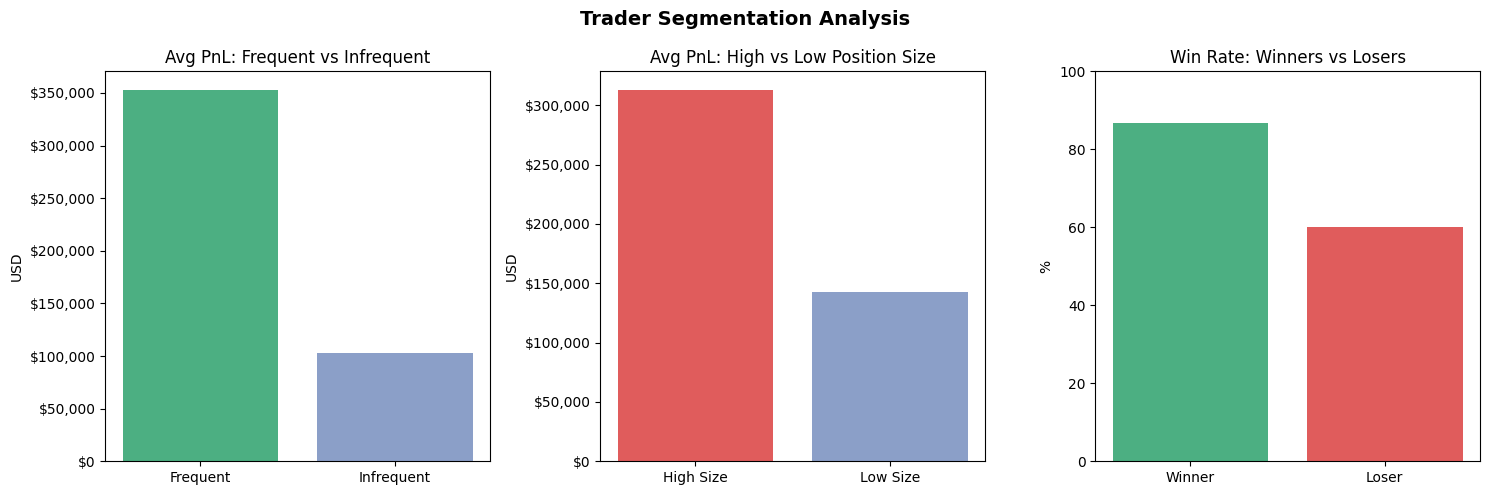

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Trader Segmentation Analysis', 
             fontsize=14, fontweight='bold')

# Chart 1 — Frequent vs Infrequent
seg1 = seg_summary.set_index('segment')
x1 = ['Frequent', 'Infrequent']
axes[0].bar(x1, seg1.loc[x1, 'avg_pnl'],
            color=['#4caf82', '#8b9fc8'])
axes[0].set_title('Avg PnL: Frequent vs Infrequent')
axes[0].set_ylabel('USD')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Chart 2 — High vs Low Size
seg2 = seg_summary2.set_index('segment')
x2 = ['High Size', 'Low Size']
axes[1].bar(x2, seg2.loc[x2, 'avg_pnl'],
            color=['#e05c5c', '#8b9fc8'])
axes[1].set_title('Avg PnL: High vs Low Position Size')
axes[1].set_ylabel('USD')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Chart 3 — Winners vs Losers win rate
seg3 = seg_summary3.set_index('segment')
x3 = ['Winner', 'Loser']
axes[2].bar(x3, seg3.loc[x3, 'avg_winrate'] * 100,
            color=['#4caf82', '#e05c5c'])
axes[2].set_title('Win Rate: Winners vs Losers')
axes[2].set_ylabel('%')
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('segmentation.png', dpi=150, bbox_inches='tight')
plt.show()



- traders who traded frequently **made 3.4× more money.** 

- traders with larger positions **earned 2.2× more.** But they were also slightly less accurate.

- losing traders actually placed bigger trades than winners.
  The real problem was accuracy - **winners hit 87% win rate,
  losers only 60%.**

In [88]:
# Supporting stats for Part C
fear_days  = daily[daily['sentiment'] == 'Fear']
greed_days = daily[daily['sentiment'] == 'Greed']

print("% profitable days — Fear :", 
      round((fear_days['total_pnl'] > 0).mean() * 100, 1))
print("% profitable days — Greed:", 
      round((greed_days['total_pnl'] > 0).mean() * 100, 1))

print("\nFear days avg PnL  :", round(fear_days['total_pnl'].mean(), 2))
print("Greed days avg PnL :", round(greed_days['total_pnl'].mean(), 2))

print("\nWinners avg win rate :", round(trader[trader['pnl_segment']=='Winner']['win_rate'].mean() * 100, 1))
print("Losers avg win rate  :", round(trader[trader['pnl_segment']=='Loser']['win_rate'].mean() * 100, 1))

% profitable days — Fear : 90.1
% profitable days — Greed: 87.6

Fear days avg PnL  : 52332.84
Greed days avg PnL : 7185.95

Winners avg win rate : 86.8
Losers avg win rate  : 60.0


## Trader Behavioral Archetypes (KMeans Clustering)

We cluster the 32 traders based on their behavior
trade frequency, win rate, position size and long ratio
to identify natural groupings.

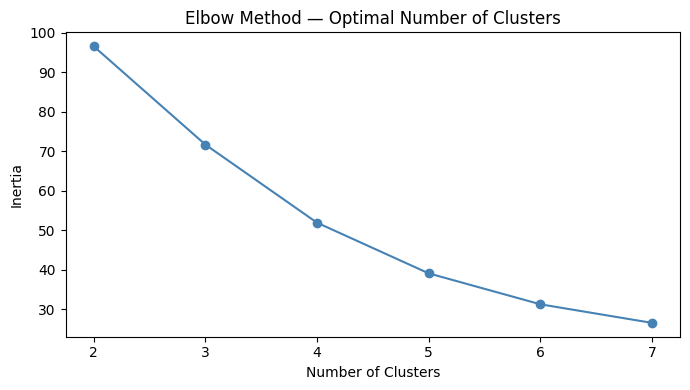

In [89]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Features for clustering
features = ['n_trades', 'win_rate', 'avg_size_usd', 'long_ratio']
X = trader[features].copy()

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal number of clusters using elbow method
inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(2, 8), inertias, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding the Right Number of Clusters (Elbow Method)

 **Elbow Method** — we run KMeans with different numbers of
clusters (2 through 7) and measure how tight the groups are (inertia).

We plot inertia vs number of clusters and look for the "elbow" point where adding more clusters stops improving much.
That's our ideal k.

**curve bends most noticeably at k=3** so no. of clusters will be 3 which is meaningful enough.

In [90]:
# Apply KMeans with k=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
trader['cluster'] = km.fit_predict(X_scaled)

# Profile each cluster
cluster_profile = trader.groupby('cluster').agg(
    n_traders    = ('account', 'count'),
    avg_pnl      = ('total_pnl', 'mean'),
    avg_trades   = ('n_trades', 'mean'),
    avg_winrate  = ('win_rate', 'mean'),
    avg_size     = ('avg_size_usd', 'mean'),
    avg_longrat  = ('long_ratio', 'mean')
).round(2)

print(cluster_profile)

         n_traders     avg_pnl  avg_trades  avg_winrate   avg_size  \
cluster                                                              
0               14 245792.9400   1805.9300       0.7900  5185.7800   
1               13 217568.1100   3731.9200       0.9300  3426.1800   
2                5 204154.1900   2177.4000       0.7700 25203.3300   

         avg_longrat  
cluster               
0             0.2300  
1             0.8100  
2             0.7500  


In [91]:
# Recreate archetype column
cluster_names = {0: 'Contrarian Shorters', 
                 1: 'Disciplined Scalpers', 
                 2: 'High Roller Longs'}
trader['archetype'] = trader['cluster'].map(cluster_names)

# Verify
print(trader['archetype'].value_counts())

archetype
Contrarian Shorters     14
Disciplined Scalpers    13
High Roller Longs        5
Name: count, dtype: int64


### Cluster Profiles

Three distinct trader archetypes :

**Cluster 0 — Contrarian Shorters (14 traders)**

**Cluster 1 — Disciplined Scalpers (13 traders)**

**Cluster 2 — High Roller Longs (5 traders)**


                      n_traders     avg_pnl  avg_trades  avg_winrate  \
archetype                                                              
Contrarian Shorters          14 245792.9400   1805.9300       0.7900   
Disciplined Scalpers         13 217568.1100   3731.9200       0.9300   
High Roller Longs             5 204154.1900   2177.4000       0.7700   

                       avg_size  avg_longrat  
archetype                                     
Contrarian Shorters   5185.7800       0.2300  
Disciplined Scalpers  3426.1800       0.8100  
High Roller Longs    25203.3300       0.7500  


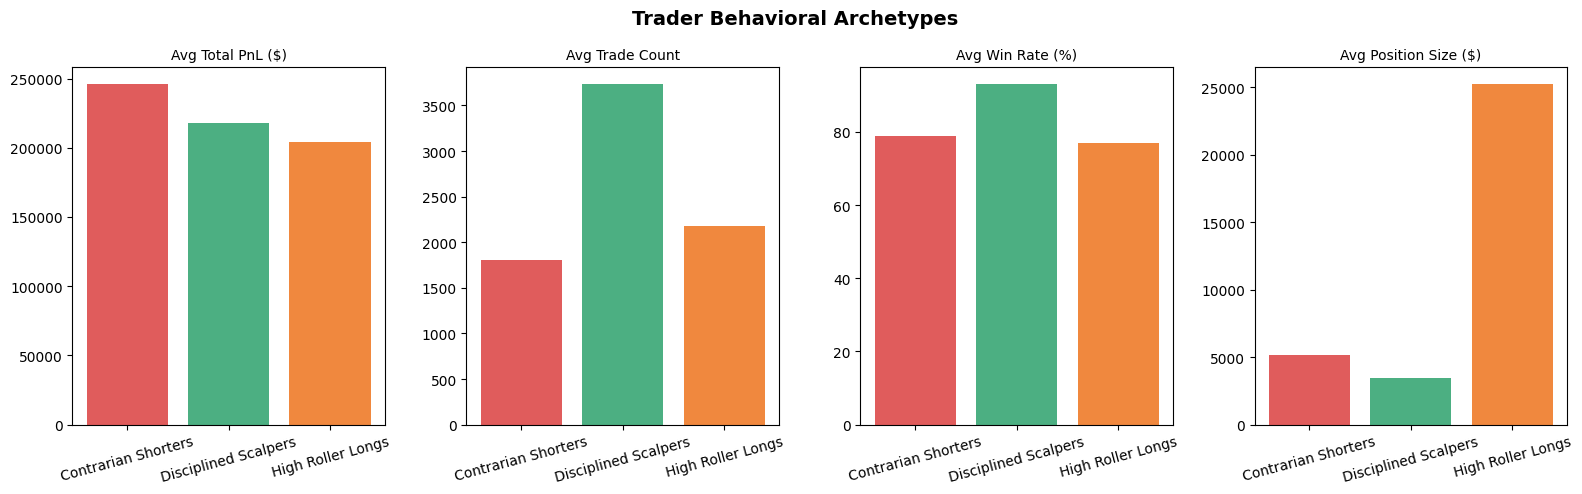

In [92]:
#Assign names
cluster_profile = trader.groupby('archetype').agg(
    n_traders   = ('account', 'count'),
    avg_pnl     = ('total_pnl', 'mean'),
    avg_trades  = ('n_trades', 'mean'),
    avg_winrate = ('win_rate', 'mean'),
    avg_size    = ('avg_size_usd', 'mean'),
    avg_longrat = ('long_ratio', 'mean')
).round(2)

print(cluster_profile)

# Chart
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Trader Behavioral Archetypes', 
             fontsize=14, fontweight='bold')

colors  = ['#e05c5c', '#4caf82', '#f0883e']
names   = cluster_profile.index.tolist()
metrics = ['avg_pnl', 'avg_trades', 'avg_winrate', 'avg_size']
titles  = ['Avg Total PnL ($)', 'Avg Trade Count', 
           'Avg Win Rate (%)', 'Avg Position Size ($)']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    vals = cluster_profile[metric].tolist()
    if metric == 'avg_winrate':
        vals = [v * 100 for v in vals]
    axes[i].bar(names, vals, color=colors)
    axes[i].set_title(title, fontsize=10)
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## Predictive Model

We can predict whether tomorrow will be a profitable day
using today's sentiment and behavior features   
  
  **Binary clasification problem**-   
- Target: was the day profitable? (1 = yes, 0 = no)
- Features: FGI value, trade count, avg position size, long ratio



In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Build the model dataset from daily metrics
model_df = daily.copy().sort_values('date')

# Target — was tomorrow profitable?
model_df['target'] = (model_df['total_pnl'].shift(-1) > 0).astype(int)

# Features
model_df['fgi_lag1']   = model_df['fgi_value'].shift(1)
model_df['pnl_lag1']   = model_df['total_pnl'].shift(1)
model_df['size_lag1']  = model_df['avg_size_usd'].shift(1)
model_df['long_lag1']  = model_df['long_ratio'].shift(1)
model_df['count_lag1'] = model_df['n_trades'].shift(1)

model_df.dropna(inplace=True)

print("Model dataset shape:", model_df.shape)
print("Target distribution:\n", model_df['target'].value_counts())

Model dataset shape: (408, 17)
Target distribution:
 target
1    359
0     49
Name: count, dtype: int64


In [94]:
features = ['fgi_lag1', 'pnl_lag1', 'size_lag1', 'long_lag1', 'count_lag1']
X = model_df[features]
y = model_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 1), "%")
print("\n", classification_report(y_test, y_pred))

Accuracy: 89.0 %

               precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.89      1.00      0.94        73

    accuracy                           0.89        82
   macro avg       0.45      0.50      0.47        82
weighted avg       0.79      0.89      0.84        82



### Predictive Model Results

The logistic regression achieved 89% accuracy, it is
misleading. Since 88% of days in our dataset were profitable,
the model simply predicted "profitable" every day and got
rewarded for it.

  ### **Strategy Recommendation -**
  
  
**Rule 1: Be More Active on Fear Days**  
if you trade regularly, increase position
sizes when FGI shows Fear. This is when the market rewards
active, sizeable trading the most. 
  
  **Rule 2: Win Rate First, Size Second**  
Infrequent traders have a slightly higher win rate (85.7%) but
trade too little to maximise it. Rather than trading every day,
they should be selective.  



findings showed that:
- Fear and Greed periods exhibited different profitability patterns.
- Trading activity changed across sentiment regimes.
- Trader segments behaved differently under varying market conditions.